# 03 — Feature Engineering

**Objective:** Encode categorical variables, create financial ratio features, and select the most predictive features for PD modeling.

**Input:** `train.csv` (829,355 x 101) and `test.csv` (462,426 x 101) from preprocessing

**Output:** Final feature matrices ready for model training — **58 features**, zero missing values, zero infinities

**Pipeline:** 101 columns → categorical encoding (116 cols) → 10 engineered ratios (126 cols) → correlation filter drops 35 → RF importance filter drops 32 → **59 columns** (58 features + target)

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Load Preprocessed Data

In [51]:
train = pd.read_csv('../data/train.csv', low_memory=False)
test = pd.read_csv('../data/test.csv', low_memory=False)

print(f"Train: {train.shape}  |  Default rate: {train['default'].mean():.4f}")
print(f"Test:  {test.shape}  |  Default rate: {test['default'].mean():.4f}")

cat_cols = train.select_dtypes(include='object').columns.tolist()
print(f"\nCategorical columns ({len(cat_cols)}): {cat_cols}")

Train: (829355, 101)  |  Default rate: 0.1846
Test:  (462426, 101)  |  Default rate: 0.2323

Categorical columns (5): ['sub_grade', 'home_ownership', 'verification_status', 'purpose', 'addr_state']


## 2. Categorical Encoding

### 2.1 Sub-Grade — ordinal encoding (A1=0 → G5=34)

Sub-grade has a natural order that directly maps to risk. Ordinal encoding preserves this monotonic relationship.

**Result:** Encoded range [0, 34]. Correlation with default r = 0.2637 — the strongest single-feature linear relationship, confirming the monotonic risk ordering across all 35 sub-grades.

Sub-grade encoded range: [0, 34]
Correlation (sub_grade_encoded vs default): 0.2637


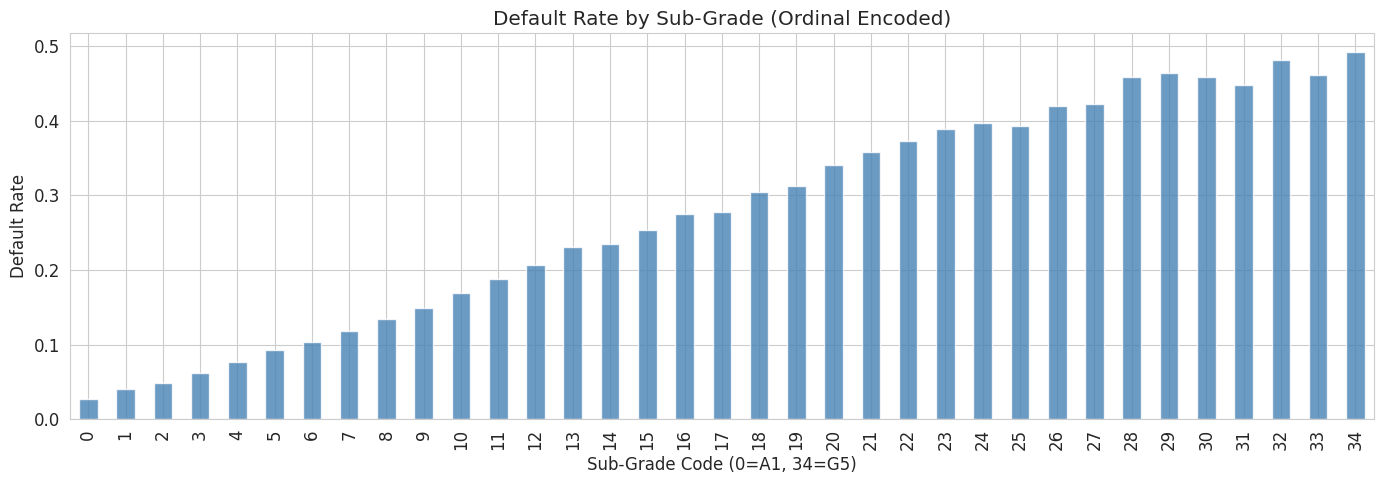

In [52]:
grades = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
sub_grades = [f'{g}{n}' for g in grades for n in range(1, 6)]
sub_grade_map = {sg: i for i, sg in enumerate(sub_grades)}

train['sub_grade_encoded'] = train['sub_grade'].map(sub_grade_map)
test['sub_grade_encoded'] = test['sub_grade'].map(sub_grade_map)

# Verify monotonic relationship with default rate
sg_default = train.groupby('sub_grade_encoded')['default'].mean()
print(f"Sub-grade encoded range: [{train['sub_grade_encoded'].min()}, {train['sub_grade_encoded'].max()}]")
print(f"Correlation (sub_grade_encoded vs default): {train['sub_grade_encoded'].corr(train['default']):.4f}")

fig, ax = plt.subplots(figsize=(14, 5))
sg_default.plot(kind='bar', ax=ax, color='steelblue', alpha=0.8)
ax.set_title('Default Rate by Sub-Grade (Ordinal Encoded)')
ax.set_xlabel('Sub-Grade Code (0=A1, 34=G5)')
ax.set_ylabel('Default Rate')
plt.tight_layout()
plt.show()

train.drop(columns=['sub_grade'], inplace=True)
test.drop(columns=['sub_grade'], inplace=True)

### 2.2 Home Ownership — one-hot encoding (4 categories)

Categories: MORTGAGE (410,712), RENT (336,799), OWN (81,609), OTHER (235). MORTGAGE dropped as baseline (most frequent). Created 3 dummy columns: `home_OTHER`, `home_OWN`, `home_RENT`.

In [53]:
print(f"Categories: {train['home_ownership'].value_counts().to_dict()}")

train = pd.get_dummies(train, columns=['home_ownership'], prefix='home', drop_first=True)
test = pd.get_dummies(test, columns=['home_ownership'], prefix='home', drop_first=True)

home_cols = [c for c in train.columns if c.startswith('home_')]
print(f"Created columns: {home_cols}")

# Align test columns with train (in case of missing categories)
for col in home_cols:
    if col not in test.columns:
        test[col] = 0

Categories: {'MORTGAGE': 410712, 'RENT': 336799, 'OWN': 81609, 'OTHER': 235}
Created columns: ['home_OTHER', 'home_OWN', 'home_RENT']


### 2.3 Verification Status — one-hot encoding (3 categories)

Categories: Source Verified (308,819), Verified (274,608), Not Verified (245,928). Not Verified dropped as baseline. Created 2 dummy columns: `verif_Source Verified`, `verif_Verified`.

In [54]:
print(f"Categories: {train['verification_status'].value_counts().to_dict()}")

train = pd.get_dummies(train, columns=['verification_status'], prefix='verif', drop_first=True)
test = pd.get_dummies(test, columns=['verification_status'], prefix='verif', drop_first=True)

verif_cols = [c for c in train.columns if c.startswith('verif_')]
print(f"Created columns: {verif_cols}")

for col in verif_cols:
    if col not in test.columns:
        test[col] = 0

Categories: {'Source Verified': 308819, 'Verified': 274608, 'Not Verified': 245928}
Created columns: ['verif_Source Verified', 'verif_Verified']


### 2.4 Purpose — one-hot encoding (14 categories)

14 loan purposes led by debt_consolidation (488,331) and credit_card (191,291). Smallest categories: renewable_energy (561) and educational (423). Created 13 dummy columns (debt_consolidation dropped as baseline).

In [55]:
print(f"Categories ({train['purpose'].nunique()}): {train['purpose'].value_counts().to_dict()}")

train = pd.get_dummies(train, columns=['purpose'], prefix='purpose', drop_first=True)
test = pd.get_dummies(test, columns=['purpose'], prefix='purpose', drop_first=True)

purpose_cols = [c for c in train.columns if c.startswith('purpose_')]
print(f"\nCreated {len(purpose_cols)} dummy columns")

for col in purpose_cols:
    if col not in test.columns:
        test[col] = 0

Categories (14): {'debt_consolidation': 488331, 'credit_card': 191291, 'home_improvement': 48509, 'other': 41249, 'major_purchase': 16387, 'small_business': 9994, 'car': 8537, 'medical': 8222, 'moving': 5269, 'vacation': 4661, 'house': 3574, 'wedding': 2347, 'renewable_energy': 561, 'educational': 423}

Created 13 dummy columns


### 2.5 State — target encoding

51 states is too many for one-hot (would add 50 sparse columns). Target encoding replaces each state with its smoothed mean default rate from the training set (smoothing=100 toward global mean 18.46%).

**Result:** Encoding range [0.1259, 0.2500]. Highest-risk states: NE (25.0%), MS (24.1%), AL (22.2%). Lowest-risk: DC (12.6%), NH (13.3%), VT (13.5%). The ~2x spread between safest and riskiest states adds meaningful geographic signal.

After all encoding: Train (829,355 x 116), Test (462,426 x 116). Zero remaining object columns.

In [56]:
global_mean = train['default'].mean()
smoothing = 100  # regularization strength

state_stats = train.groupby('addr_state')['default'].agg(['mean', 'count'])
state_stats['smoothed'] = (
    (state_stats['count'] * state_stats['mean'] + smoothing * global_mean) /
    (state_stats['count'] + smoothing)
)
state_encode_map = state_stats['smoothed'].to_dict()

train['state_default_rate'] = train['addr_state'].map(state_encode_map)
test['state_default_rate'] = test['addr_state'].map(state_encode_map)
# Unseen states in test get global mean
test['state_default_rate'].fillna(global_mean, inplace=True)

print(f"State encoding range: [{train['state_default_rate'].min():.4f}, {train['state_default_rate'].max():.4f}]")
print(f"Global mean default rate: {global_mean:.4f}")

# Show top/bottom states
print(f"\nHighest default rate states:")
print(state_stats.sort_values('smoothed', ascending=False).head(5))
print(f"\nLowest default rate states:")
print(state_stats.sort_values('smoothed', ascending=True).head(5))

train.drop(columns=['addr_state'], inplace=True)
test.drop(columns=['addr_state'], inplace=True)

State encoding range: [0.1259, 0.2500]
Global mean default rate: 0.1846

Highest default rate states:
             mean  count  smoothed
addr_state                        
NE         0.2562   1046    0.2500
MS         0.2425   3390    0.2408
AL         0.2219  10393    0.2215
AR         0.2203   6177    0.2198
OK         0.2201   7491    0.2197

Lowest default rate states:
             mean  count  smoothed
addr_state                        
DC         0.1233   2327    0.1259
NH         0.1313   3960    0.1326
VT         0.1317   1610    0.1348
OR         0.1407  10320    0.1411
CO         0.1481  17797    0.1483


In [57]:
print(f"\nAfter encoding — Train: {train.shape}, Test: {test.shape}")
print(f"Remaining object columns: {train.select_dtypes(include='object').columns.tolist()}")


After encoding — Train: (829355, 116), Test: (462426, 116)
Remaining object columns: []


## 3. Feature Creation — Financial Ratios

Creating 10 domain-specific features that capture borrower risk better than raw values alone. These fall into five groups: income-based ratios, credit capacity, account activity, delinquency intensity, and installment burden.

**Result:** Shape expanded from (829,355 x 116) to (829,355 x 126). Strongest engineered correlations with default:
- `installment_pct_of_loan` (r = -0.0927) — captures term/rate effect
- `available_credit` (r = -0.0639) — higher unused credit = lower risk
- `active_ratio` (r = 0.0450) — more open accounts relative to total = higher risk
- `available_credit_pct` (r = -0.0367) — percentage-based utilization capacity

The income-based ratios (`loan_to_income` r=0.0006, `installment_to_income` r=0.0052) show weak linear correlation but may capture non-linear interactions in tree models.

In [58]:
def create_features(df):
    """Create financial ratio features on a dataframe."""
    # Income-based ratios
    df['loan_to_income'] = df['loan_amnt'] / (df['annual_inc'] + 1)
    df['installment_to_income'] = df['installment'] / (df['annual_inc'] / 12 + 1)
    df['revol_bal_to_income'] = df['revol_bal'] / (df['annual_inc'] + 1)
    
    # Credit utilization and capacity
    df['available_credit'] = df['total_rev_hi_lim'] - df['revol_bal']
    df['available_credit_pct'] = df['available_credit'] / (df['total_rev_hi_lim'] + 1)
    
    # Account activity
    df['active_ratio'] = df['open_acc'] / (df['total_acc'] + 1)
    
    # Delinquency intensity
    df['delinq_per_account'] = df['delinq_2yrs'] / (df['total_acc'] + 1)
    df['pub_rec_per_account'] = df['pub_rec'] / (df['total_acc'] + 1)
    
    # Installment burden relative to loan
    df['installment_pct_of_loan'] = df['installment'] / (df['loan_amnt'] + 1)
    
    # Credit history depth
    df['accounts_per_year'] = df['total_acc'] / (df['credit_history_months'] / 12 + 1)
    
    return df

train = create_features(train)
test = create_features(test)

new_features = ['loan_to_income', 'installment_to_income', 'revol_bal_to_income',
                'available_credit', 'available_credit_pct', 'active_ratio',
                'delinq_per_account', 'pub_rec_per_account',
                'installment_pct_of_loan', 'accounts_per_year']

print(f"Created {len(new_features)} new features")
print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")

Created 10 new features
Train shape: (829355, 126)
Test shape:  (462426, 126)


In [59]:
# Check new feature distributions and correlation with default
print("New feature correlations with default:")
for feat in new_features:
    corr = train[feat].corr(train['default'])
    print(f"  {feat:<30} r = {corr:>7.4f}")

New feature correlations with default:
  loan_to_income                 r =  0.0006
  installment_to_income          r =  0.0052
  revol_bal_to_income            r =  0.0020
  available_credit               r = -0.0639
  available_credit_pct           r = -0.0367
  active_ratio                   r =  0.0450
  delinq_per_account             r =  0.0134
  pub_rec_per_account            r =  0.0154
  installment_pct_of_loan        r = -0.0927
  accounts_per_year              r =  0.0339


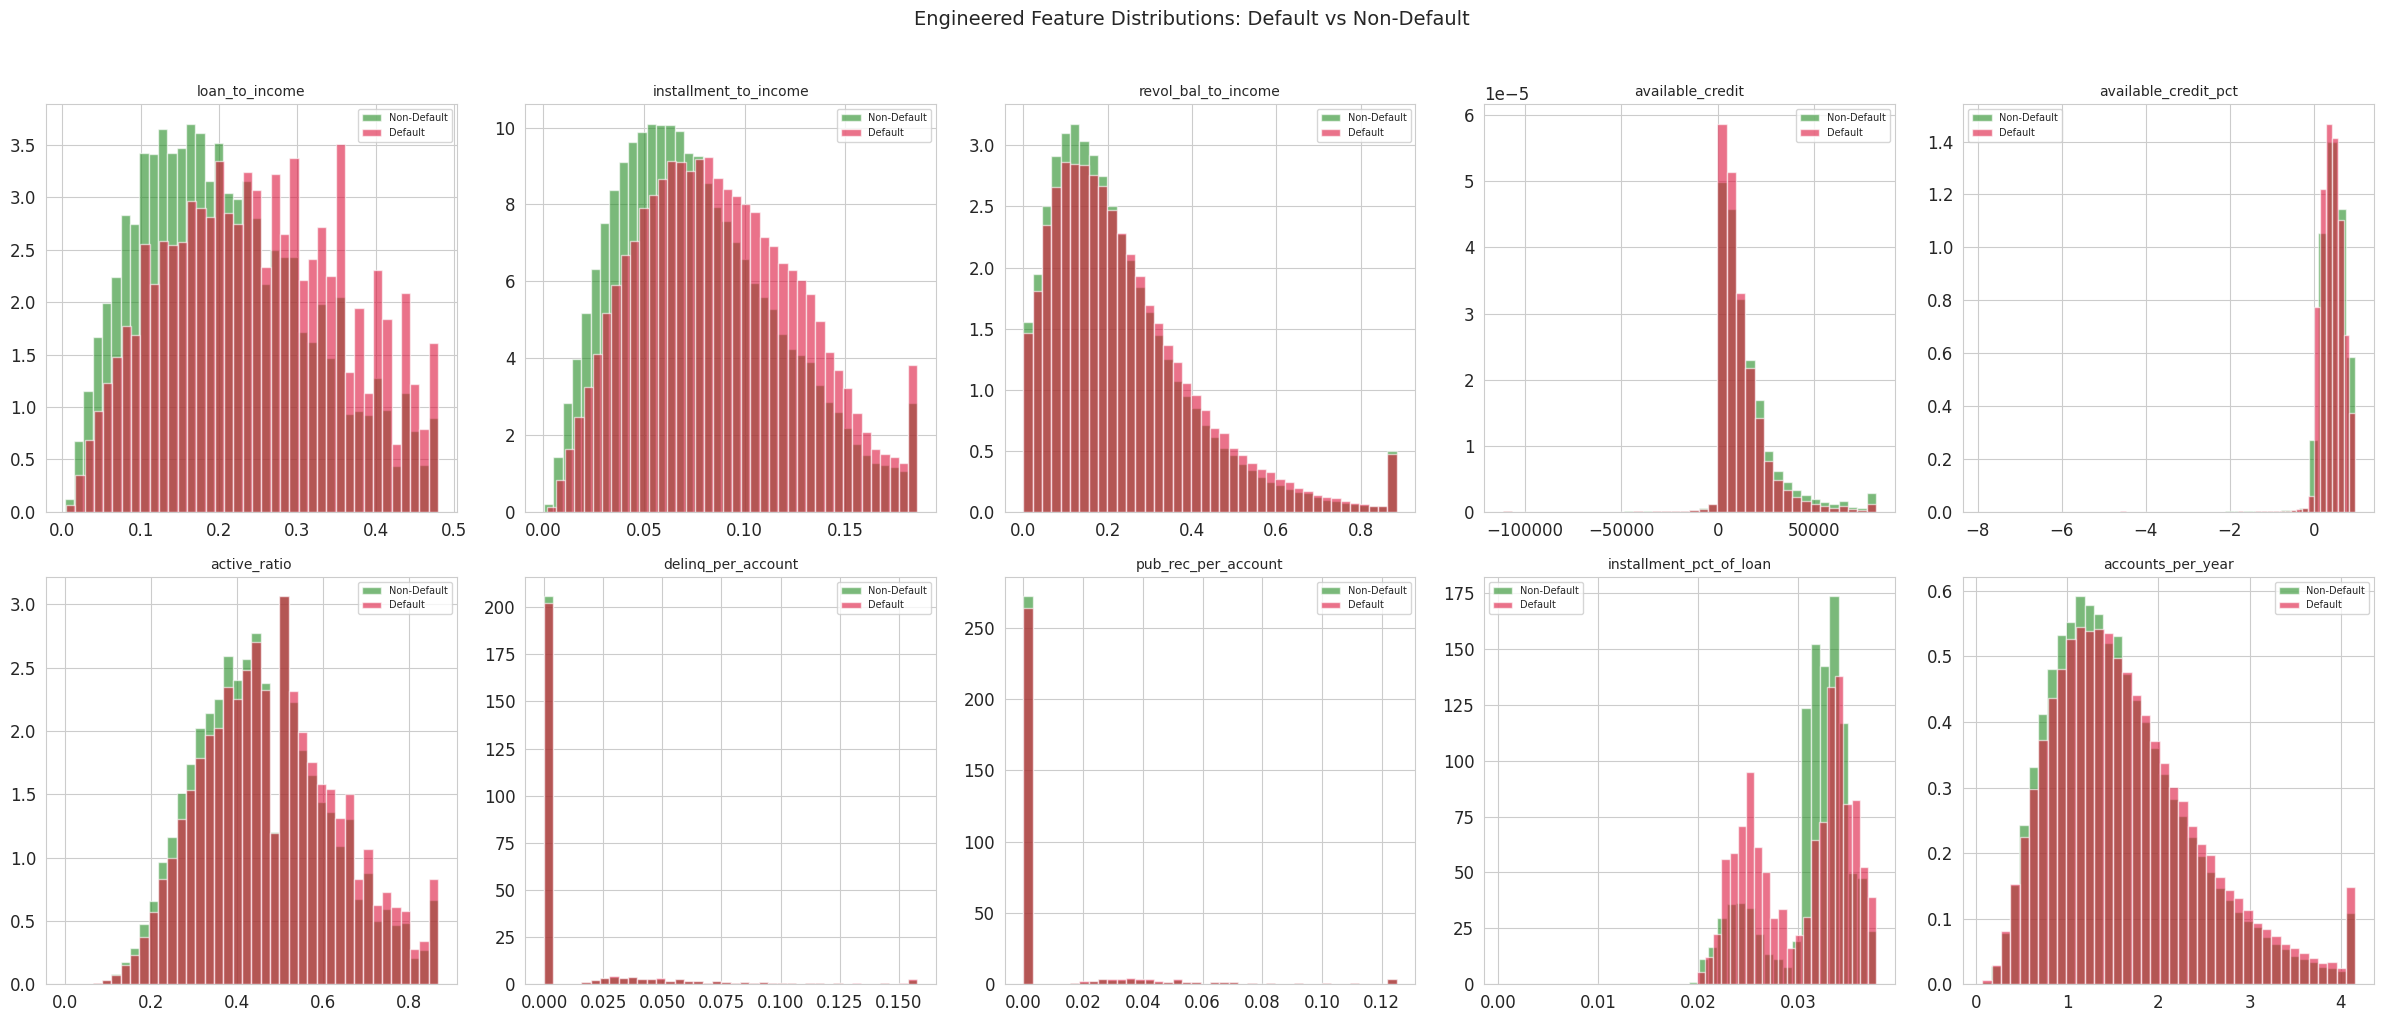

In [60]:
fig, axes = plt.subplots(2, 5, figsize=(24, 10))
axes = axes.flatten()

for i, feat in enumerate(new_features):
    data = train[feat].clip(upper=train[feat].quantile(0.99))
    data_0 = data[train['default'] == 0]
    data_1 = data[train['default'] == 1]
    
    axes[i].hist(data_0, bins=40, alpha=0.6, color='forestgreen',
                 label='Non-Default', density=True)
    axes[i].hist(data_1, bins=40, alpha=0.6, color='crimson',
                 label='Default', density=True)
    axes[i].set_title(feat, fontsize=10)
    axes[i].legend(fontsize=7)

plt.suptitle('Engineered Feature Distributions: Default vs Non-Default', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. Handle Infinite / Extreme Values in New Features

**Result:** No inf or NaN values were introduced by the ratio calculations (denominators all had +1 safeguard). All 10 new features capped at 99.5th percentile for consistency with preprocessing. Final NaN count: 0 in both train and test.

In [61]:
# Replace inf values and cap extreme ratios
for df in [train, test]:
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Check for any NaN introduced
nan_counts = train[new_features].isnull().sum()
if nan_counts.sum() > 0:
    print("NaN values in new features (from inf replacement):")
    print(nan_counts[nan_counts > 0])
    # Fill with median
    for col in new_features:
        if train[col].isnull().any():
            med = train[col].median()
            train[col].fillna(med, inplace=True)
            test[col].fillna(med, inplace=True)
else:
    print("No inf/NaN values in new features.")

# Cap new features at 99.5th percentile
for col in new_features:
    upper = train[col].quantile(0.995)
    train[col] = train[col].clip(upper=upper)
    test[col] = test[col].clip(upper=upper)

print(f"\nAll new features capped at 99.5th percentile.")
print(f"Total NaN in train: {train.isnull().sum().sum()}")
print(f"Total NaN in test:  {test.isnull().sum().sum()}")

No inf/NaN values in new features.

All new features capped at 99.5th percentile.
Total NaN in train: 0
Total NaN in test:  0


## 5. Feature Selection

### 5.1 Remove highly correlated feature pairs

Drop one from each pair where |r| > 0.90 to reduce multicollinearity. For each pair, keep the feature with stronger correlation to the target.

**Result:** Found 295 feature pairs with |r| > 0.90. The vast majority were among `_missing` indicator flags (many had r = 1.000, meaning identical missingness patterns). Notable non-missing pairs: `int_rate` ↔ `sub_grade_encoded` (r=0.976), `open_acc` ↔ `num_sats` (r=0.966), `tot_cur_bal` ↔ `tot_hi_cred_lim` (r=0.953), `loan_amnt` ↔ `installment` (r=0.952). Dropped **35 features**, reducing shape from (829,355 x 126) to (829,355 x 91).

In [62]:
feature_cols = [c for c in train.columns if c != 'default']
corr_matrix = train[feature_cols].corr().abs()

# Find pairs with correlation > 0.90
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = []
for col in upper_tri.columns:
    for idx in upper_tri.index:
        if upper_tri.loc[idx, col] > 0.90:
            high_corr_pairs.append((idx, col, upper_tri.loc[idx, col]))

print(f"Feature pairs with |r| > 0.90: {len(high_corr_pairs)}")
for f1, f2, r in sorted(high_corr_pairs, key=lambda x: -x[2]):
    print(f"  {f1:<40} — {f2:<40} r={r:.3f}")

Feature pairs with |r| > 0.90: 295
  tot_coll_amt_missing                     — tot_cur_bal_missing                      r=1.000
  tot_coll_amt_missing                     — total_rev_hi_lim_missing                 r=1.000
  tot_cur_bal_missing                      — total_rev_hi_lim_missing                 r=1.000
  mo_sin_old_rev_tl_op_missing             — mo_sin_rcnt_rev_tl_op_missing            r=1.000
  tot_coll_amt_missing                     — mo_sin_rcnt_tl_missing                   r=1.000
  tot_cur_bal_missing                      — mo_sin_rcnt_tl_missing                   r=1.000
  total_rev_hi_lim_missing                 — mo_sin_rcnt_tl_missing                   r=1.000
  acc_open_past_24mths_missing             — mort_acc_missing                         r=1.000
  tot_coll_amt_missing                     — num_accts_ever_120_pd_missing            r=1.000
  tot_cur_bal_missing                      — num_accts_ever_120_pd_missing            r=1.000
  total_rev_hi_lim_missin

In [63]:
# For each correlated pair, drop the one with lower correlation to the target
target_corr = train[feature_cols].corrwith(train['default']).abs()

cols_to_drop = set()
for f1, f2, r in high_corr_pairs:
    if f1 in cols_to_drop or f2 in cols_to_drop:
        continue
    # Keep the feature more correlated with default
    if target_corr.get(f1, 0) >= target_corr.get(f2, 0):
        cols_to_drop.add(f2)
    else:
        cols_to_drop.add(f1)

print(f"Dropping {len(cols_to_drop)} features due to high correlation:")
for col in sorted(cols_to_drop):
    print(f"  - {col}")

train.drop(columns=list(cols_to_drop), inplace=True)
test.drop(columns=list(cols_to_drop), inplace=True)

print(f"\nTrain shape after correlation filter: {train.shape}")

Dropping 35 features due to high correlation:
  - acc_open_past_24mths_missing
  - avg_cur_bal_missing
  - bc_open_to_buy_missing
  - bc_util_missing
  - installment
  - installment_to_income
  - int_rate
  - mo_sin_old_rev_tl_op_missing
  - mo_sin_rcnt_rev_tl_op_missing
  - mo_sin_rcnt_tl_missing
  - mort_acc_missing
  - mths_since_recent_bc_missing
  - num_accts_ever_120_pd_missing
  - num_actv_bc_tl_missing
  - num_actv_rev_tl
  - num_actv_rev_tl_missing
  - num_bc_tl_missing
  - num_il_tl_missing
  - num_op_rev_tl_missing
  - num_rev_accts_missing
  - num_rev_tl_bal_gt_0_missing
  - num_sats
  - num_sats_missing
  - num_tl_30dpd_missing
  - num_tl_90g_dpd_24m_missing
  - num_tl_op_past_12m_missing
  - pct_tl_nvr_dlq_missing
  - tot_coll_amt_missing
  - tot_cur_bal
  - tot_cur_bal_missing
  - tot_hi_cred_lim_missing
  - total_bal_ex_mort_missing
  - total_bc_limit_missing
  - total_il_high_credit_limit_missing
  - total_rev_hi_lim_missing

Train shape after correlation filter: (8293

### 5.2 Feature importance — quick Random Forest

Train a shallow random forest (200 trees, max_depth=10) on a 100K sample to rank features by importance.

**Result — Top 10:**
1. `sub_grade_encoded` (0.2054) — dominates, as expected
2. `installment_pct_of_loan` (0.1531) — engineered feature ranks #2
3. `term` (0.0949) — 36 vs 60 months is a strong risk signal
4. `loan_to_income` (0.0508) — another engineered feature in top 5
5. `fico_score` (0.0386)
6. `dti` (0.0309)
7. `acc_open_past_24mths` (0.0246)
8. `avg_cur_bal` (0.0228)
9. `bc_open_to_buy` (0.0210)
10. `tot_hi_cred_lim` (0.0205)

Engineered features contributed 3 of the top 10, validating the feature creation step.

In [64]:
feature_cols = [c for c in train.columns if c != 'default']
X_sample = train[feature_cols].sample(n=min(100000, len(train)), random_state=42)
y_sample = train.loc[X_sample.index, 'default']

rf = RandomForestClassifier(
    n_estimators=200, max_depth=10, min_samples_leaf=50,
    random_state=42, n_jobs=-1, class_weight='balanced'
)
rf.fit(X_sample, y_sample)

importance = pd.Series(rf.feature_importances_, index=feature_cols)
importance = importance.sort_values(ascending=False)

print(f"Top 30 features by importance:")
for i, (feat, imp) in enumerate(importance.head(30).items()):
    print(f"  {i+1:>2}. {feat:<40} {imp:.4f}")

Top 30 features by importance:
   1. sub_grade_encoded                        0.2054
   2. installment_pct_of_loan                  0.1531
   3. term                                     0.0949
   4. loan_to_income                           0.0508
   5. fico_score                               0.0386
   6. dti                                      0.0309
   7. acc_open_past_24mths                     0.0246
   8. avg_cur_bal                              0.0228
   9. bc_open_to_buy                           0.0210
  10. tot_hi_cred_lim                          0.0205
  11. annual_inc                               0.0190
  12. loan_amnt                                0.0174
  13. available_credit                         0.0153
  14. total_bc_limit                           0.0153
  15. total_rev_hi_lim                         0.0126
  16. num_tl_op_past_12m                       0.0118
  17. mths_since_recent_bc                     0.0116
  18. mo_sin_rcnt_tl                           0.01

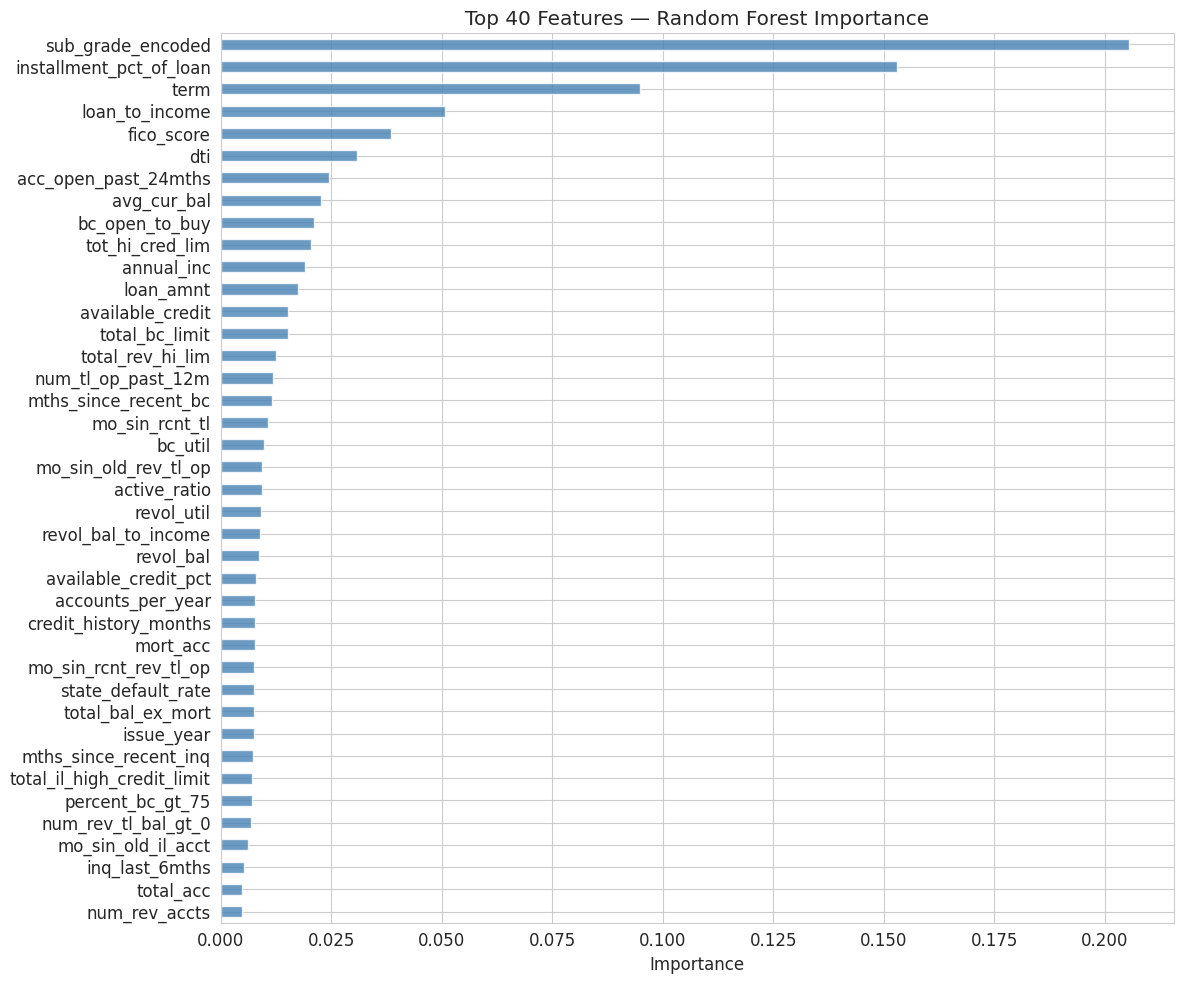

In [65]:
fig, ax = plt.subplots(figsize=(12, 10))
importance.head(40).plot(kind='barh', ax=ax, color='steelblue', alpha=0.8)
ax.set_title('Top 40 Features — Random Forest Importance')
ax.set_xlabel('Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [66]:
# Show near-zero importance features (candidates for removal)
low_imp = importance[importance < 0.001]
print(f"\nFeatures with importance < 0.001: {len(low_imp)}")
for feat, imp in low_imp.items():
    print(f"  {feat:<40} {imp:.6f}")


Features with importance < 0.001: 32
  verif_Source Verified                    0.000949
  mths_since_recent_inq_missing            0.000895
  delinq_2yrs                              0.000825
  emp_length_missing                       0.000825
  pub_rec                                  0.000476
  pub_rec_bankruptcies                     0.000379
  mo_sin_old_il_acct_missing               0.000277
  num_tl_120dpd_2m_missing                 0.000230
  home_OWN                                 0.000211
  num_bc_sats_missing                      0.000178
  purpose_home_improvement                 0.000144
  purpose_small_business                   0.000138
  percent_bc_gt_75_missing                 0.000133
  purpose_other                            0.000126
  num_tl_90g_dpd_24m                       0.000110
  tax_liens                                0.000032
  collections_12_mths_ex_med               0.000005
  purpose_major_purchase                   0.000005
  acc_now_delinq          

### 5.3 Drop near-zero importance features

Remove features with importance < 0.001 — these add noise without predictive value.

**Result:** Dropped **32 features** including all remaining `_missing` indicator flags, rare purpose dummies (wedding, moving, vacation, renewable_energy, educational), near-constant features (`acc_now_delinq`, `chargeoff_within_12_mths`, `delinq_amnt`, `num_tl_30dpd`, `num_tl_120dpd_2m`), and `is_joint_app`. Final shape: (829,355 x 59).

In [67]:
drop_low_imp = low_imp.index.tolist()

if len(drop_low_imp) > 0:
    train.drop(columns=drop_low_imp, inplace=True)
    test.drop(columns=drop_low_imp, inplace=True)
    print(f"Dropped {len(drop_low_imp)} low-importance features")
else:
    print("No features below importance threshold")

print(f"Final train shape: {train.shape}")
print(f"Final test shape:  {test.shape}")

Dropped 32 low-importance features
Final train shape: (829355, 59)
Final test shape:  (462426, 59)


## 6. Final Feature Set Overview

**58 features** across these categories:
- **Numeric (54):** credit bureau variables, financial ratios, account metrics, encoded state default rate
- **Boolean (3):** `home_RENT`, `purpose_credit_card`, `purpose_debt_consolidation`, `verif_Verified`
- **Integer (4):** `sub_grade_encoded`, `term`, `initial_list_status`, `issue_month`, `issue_year`

In [68]:
feature_cols = [c for c in train.columns if c != 'default']

print(f"Final feature count: {len(feature_cols)}")
print(f"Train: {train.shape}, Test: {test.shape}")
print(f"\nAll features:")
for i, col in enumerate(sorted(feature_cols)):
    print(f"  {i+1:>3}. {col:<45} {str(train[col].dtype)}")

Final feature count: 58
Train: (829355, 59), Test: (462426, 59)

All features:
    1. acc_open_past_24mths                          float64
    2. accounts_per_year                             float64
    3. active_ratio                                  float64
    4. annual_inc                                    float64
    5. available_credit                              float64
    6. available_credit_pct                          float64
    7. avg_cur_bal                                   float64
    8. bc_open_to_buy                                float64
    9. bc_util                                       float64
   10. credit_history_months                         float64
   11. delinq_per_account                            float64
   12. dti                                           float64
   13. emp_length                                    float64
   14. fico_score                                    float64
   15. home_RENT                                     bool
   16. in

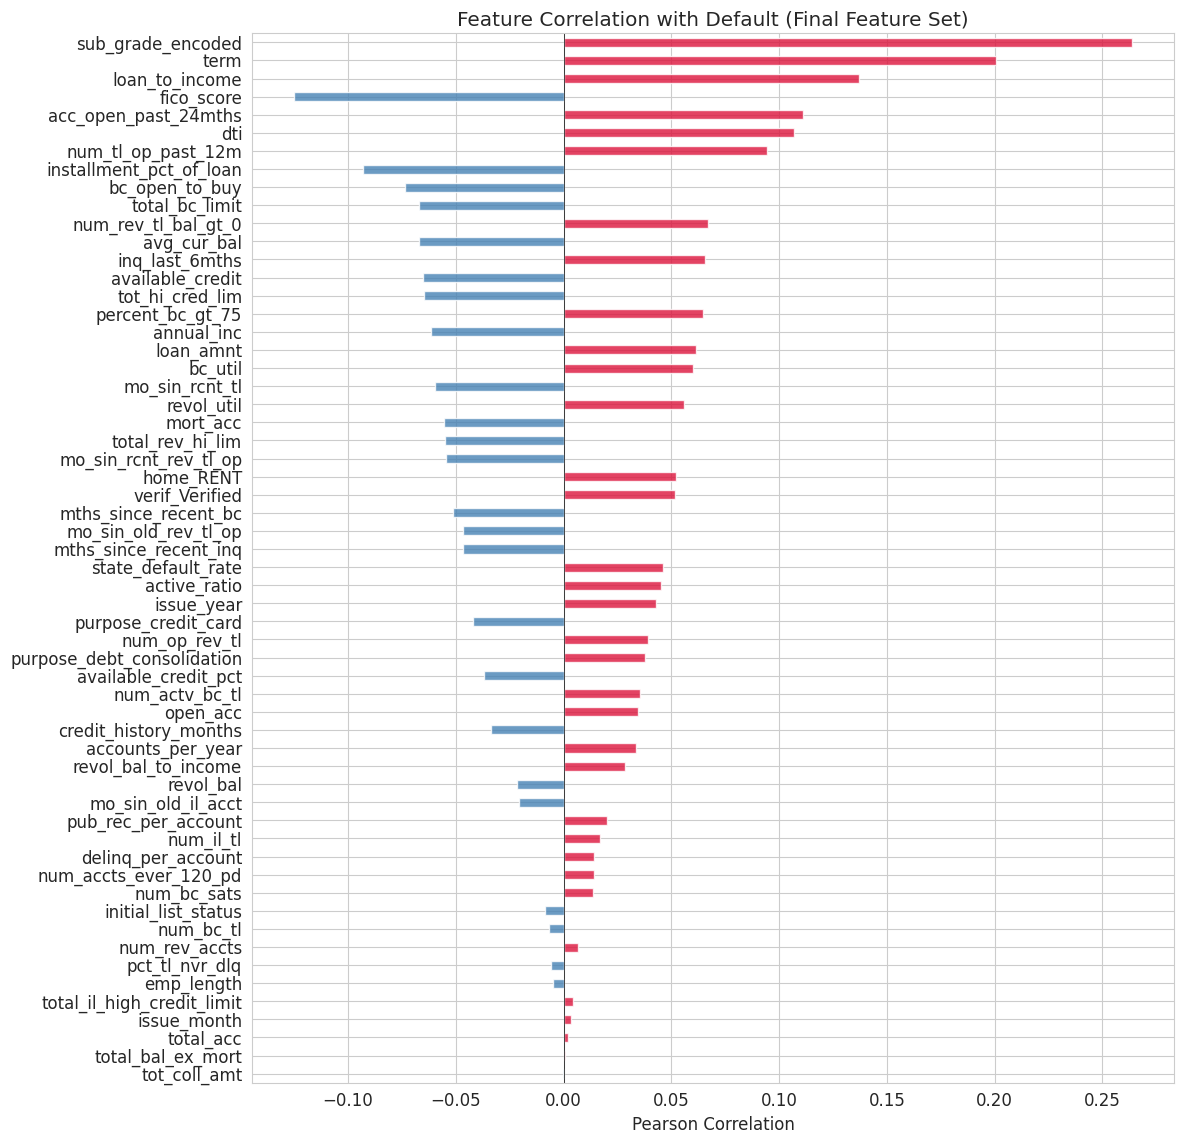

In [69]:
# Correlation with default — final feature set
final_corr = train[feature_cols].corrwith(train['default']).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(12, max(8, len(feature_cols) * 0.2)))
colors = ['crimson' if v > 0 else 'steelblue' for v in final_corr.values]
final_corr.plot(kind='barh', ax=ax, color=colors, alpha=0.8)
ax.set_title('Feature Correlation with Default (Final Feature Set)')
ax.set_xlabel('Pearson Correlation')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Prepare Final Arrays and Save

- **X_train:** (829,355 x 58) — default rate 18.46%
- **X_test:** (462,426 x 58) — default rate 23.23%
- Missing values: 0 | Inf values: 0

In [70]:
feature_cols = [c for c in train.columns if c != 'default']

X_train = train[feature_cols]
y_train = train['default']
X_test = test[feature_cols]
y_test = test['default']

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}  (default rate: {y_train.mean():.4f})")
print(f"X_test:  {X_test.shape}")
print(f"y_test:  {y_test.shape}  (default rate: {y_test.mean():.4f})")
print(f"\nMissing values — X_train: {X_train.isnull().sum().sum()}, X_test: {X_test.isnull().sum().sum()}")
print(f"Inf values — X_train: {np.isinf(X_train.select_dtypes(include=[np.number])).sum().sum()}, X_test: {np.isinf(X_test.select_dtypes(include=[np.number])).sum().sum()}")

X_train: (829355, 58)
y_train: (829355,)  (default rate: 0.1846)
X_test:  (462426, 58)
y_test:  (462426,)  (default rate: 0.2323)

Missing values — X_train: 0, X_test: 0
Inf values — X_train: 0, X_test: 0


In [71]:
# Save feature-engineered datasets
train.to_csv('../data/train_fe.csv', index=False)
test.to_csv('../data/test_fe.csv', index=False)

# Save feature names for later use
pd.Series(feature_cols).to_csv('../data/feature_names.csv', index=False, header=['feature'])

print(f"Saved:")
print(f"  train_fe.csv:       {train.shape}")
print(f"  test_fe.csv:        {test.shape}")
print(f"  feature_names.csv:  {len(feature_cols)} features")

Saved:
  train_fe.csv:       (829355, 59)
  test_fe.csv:        (462426, 59)
  feature_names.csv:  58 features


## 8. Feature Engineering Summary

**Categorical Encoding (5 columns → 20 encoded features):**
- `sub_grade` → ordinal 0–34 (r = 0.2637 with default — strongest single feature)
- `home_ownership` → 3 one-hot dummies (MORTGAGE baseline)
- `verification_status` → 2 one-hot dummies (Not Verified baseline)
- `purpose` → 13 one-hot dummies (debt_consolidation baseline)
- `addr_state` → target-encoded `state_default_rate` [0.1259, 0.2500]

**Engineered Features (10 created, 6 survived selection):**
- Survived: `loan_to_income`, `available_credit`, `available_credit_pct`, `active_ratio`, `delinq_per_account`, `installment_pct_of_loan`, `revol_bal_to_income`, `accounts_per_year`, `pub_rec_per_account`
- `installment_pct_of_loan` ranked #2 in feature importance (0.1531)
- `loan_to_income` ranked #4 (0.0508)
- Dropped by correlation filter: `installment_to_income` (r=0.944 with `loan_to_income`)

**Feature Selection (126 → 59 columns):**
- Correlation filter (|r| > 0.90): 295 pairs found → dropped 35 features (mostly `_missing` flags with identical patterns, plus `int_rate` redundant with `sub_grade_encoded`)
- RF importance filter (< 0.001): dropped 32 features (remaining `_missing` flags, rare dummies, near-constant columns)

**Final Dataset:**
| | Rows | Features | Default Rate |
|---|---|---|---|
| Train (2007–2015) | 829,355 | 58 | 18.46% |
| Test (2016–2017) | 462,426 | 58 | 23.23% |

**Next Steps → Notebook 04 (PD Model):**
- Train and benchmark: Logistic Regression, Random Forest, XGBoost, LightGBM
- Hyperparameter tuning with Optuna
- Evaluate AUC, precision, recall, F1
- Probability calibration